Conducting an experiment to identify different types of land cover (like forests, water bodies, urban areas) from aerial images. 
1. DS_X_data: Contains smaller images of size 61x61 pixels.
2. Xdata: Contains larger images of size 242x242 pixels.
3. Ydata: This dataset contains the labels (type of land cover for each image in the datasets above).

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [54]:
# Load the Y data
Y_data = np.load("C:\\Users\\Dell\\Desktop\\Ydata.npy")

# Load the DS_X data
DS_X_data = np.load("C:\\Users\\Dell\\Desktop\\DS_Xdata.npy")
 
# Load the DS_X data
Xdata = np.load("C:\\Users\\Dell\\Desktop\\Xdata-1.npy")

Y_data.shape, DS_X_data.shape, Xdata.shape


((2100, 1), (2100, 61, 61, 3), (2100, 242, 242, 3))

Data Exploration

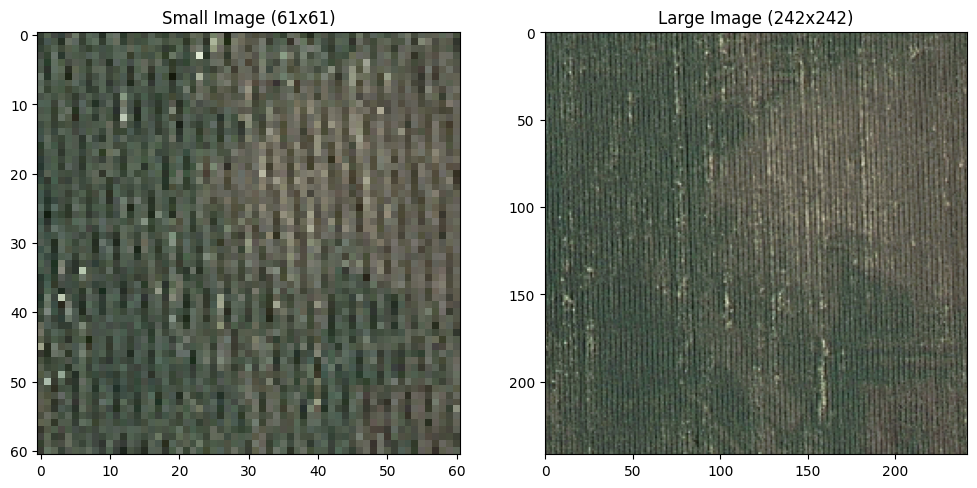

Pixel value range in DS_X_data: 0 255
Pixel value range in Xdata: 0 255
Label distribution: {0: 100, 1: 100, 2: 100, 3: 100, 4: 100, 5: 100, 6: 100, 7: 100, 8: 100, 9: 100, 10: 100, 11: 100, 12: 100, 13: 100, 14: 100, 15: 100, 16: 100, 17: 100, 18: 100, 19: 100, 20: 100}


In [55]:
# Visual inspection of images
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(DS_X_data[27])
axes[0].set_title('Small Image (61x61)')
axes[1].imshow(Xdata[27])
axes[1].set_title('Large Image (242x242)')

plt.show()

# Check pixel value ranges
print("Pixel value range in DS_X_data:", DS_X_data.min(), DS_X_data.max())
print("Pixel value range in Xdata:", Xdata.min(), Xdata.max())

# Check label distribution
unique, counts = np.unique(Y_data, return_counts=True)
label_distribution = dict(zip(unique, counts))
print("Label distribution:", label_distribution)

Data Preprocessing

In [56]:
# Normalize the image data
DS_X_data = DS_X_data / 255.0
Xdata = Xdata / 255.0

# Flatten the labels for easier processing
# Y_data.ravel() converts the label array Y_data into a one-dimensional array
Y_data_flat = Y_data.ravel()

# Split the data into training, validation, and test sets
X_train_val, X_test, Y_train_val, Y_test = train_test_split(DS_X_data, Y_data_flat, test_size=0.1, random_state=42)
X_train, X_val, Y_train, Y_val = train_test_split(X_train_val, Y_train_val, test_size=0.1111, random_state=42)

# For the larger images
Xdata_train_val, Xdata_test, Ydata_train_val, Ydata_test = train_test_split(Xdata, Y_data_flat, test_size=0.1, random_state=42)
Xdata_train, Xdata_val, Ydata_train, Ydata_val = train_test_split(Xdata_train_val, Ydata_train_val, test_size=0.1111, random_state=42)

# shapes of the split datasets
print("Training set shape:", X_train.shape)
print("Validation set shape:", X_val.shape)
print("Test set shape:", X_test.shape)

print("Training set shape for large images:", Xdata_train.shape)
print("Validation set shape for large images:", Xdata_val.shape)
print("Test set shape for large images:", Xdata_test.shape)


Training set shape: (1680, 61, 61, 3)
Validation set shape: (210, 61, 61, 3)
Test set shape: (210, 61, 61, 3)
Training set shape for large images: (1680, 242, 242, 3)
Validation set shape for large images: (210, 242, 242, 3)
Test set shape for large images: (210, 242, 242, 3)


CNN Model for Small Images (61x61)

In [57]:


# CNN architecture
model_small = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(61, 61, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(21, activation='softmax')
])

# Compile model
model_small.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Model summary
model_small.summary()

# Train model
history_small = model_small.fit(X_train, Y_train, epochs=10, 
                                validation_data=(X_val, Y_val))


c:\Users\Dell\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 59, 59, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 29, 29, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 27, 27, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 11, 11, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 7744)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       495,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 21)             │         1,365 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 553,365 (2.11 MB)

 Trainable params: 553,365 (2.11 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - accuracy: 0.0542 - loss: 3.0492 - val_accuracy: 0.0857 - val_loss: 2.9806
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.0889 - loss: 2.9233 - val_accuracy: 0.1143 - val_loss: 2.7759
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.1222 - loss: 2.7836 - val_accuracy: 0.1810 - val_loss: 2.6404
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.1395 - loss: 2.6994 - val_accuracy: 0.1952 - val_loss: 2.4524
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.1846 - loss: 2.5141 - val_accuracy: 0.2524 - val_loss: 2.3091
Epoch 6/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.2194 - loss: 2.4099 - val_accuracy: 0.2571 - val_loss: 2.3088
Epoch 7/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.2478 - loss: 2.2609 - val_accuracy: 0.3095 - val_loss: 2.1843
Epoch 8/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.3002 - loss: 2.2046 - val_accuracy: 0.3667 - v

CNN Model for Large Images (242x242)

In [58]:
# Define CNN architecture for large images
model_large = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(242, 242, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(21, activation='softmax')
])

# Compile model
model_large.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Model summary
model_large.summary()

# Train model
history_large = model_large.fit(Xdata_train, Ydata_train, epochs=10, 
                                validation_data=(Xdata_val, Ydata_val))


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 240, 240, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 120, 120, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 118, 118, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 59, 59, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 57, 57, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 21)             │         2,709 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,941,141 (49.37 MB)

 Trainable params: 12,941,141 (49.37 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 53s 956ms/step - accuracy: 0.0584 - loss: 3.4396 - val_accuracy: 0.0952 - val_loss: 3.0011
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 48s 904ms/step - accuracy: 0.0878 - loss: 3.0057 - val_accuracy: 0.1190 - val_loss: 2.8413
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 48s 902ms/step - accuracy: 0.1354 - loss: 2.8451 - val_accuracy: 0.2381 - val_loss: 2.5555
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 48s 897ms/step - accuracy: 0.2020 - loss: 2.5275 - val_accuracy: 0.2524 - val_loss: 2.3979
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 48s 911ms/step - accuracy: 0.2633 - loss: 2.2699 - val_accuracy: 0.3429 - val_loss: 2.1445
Epoch 6/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 48s 903ms/step - accuracy: 0.3834 - loss: 1.9190 - val_accuracy: 0.3476 - val_loss: 2.0291
Epoch 7/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 48s 897ms/step - accuracy: 0.4376 - loss: 1.7462 - val_accuracy: 0.3952 - val_loss: 2.0785
Epoch 8/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 52s 990ms/step - accuracy: 0.5305 - loss: 1.4412 - val_accu

Evaluate the Models

In [59]:
# Evaluate small model
test_loss_small, test_acc_small = model_small.evaluate(X_test, Y_test, verbose=2)

# Evaluate large model
test_loss_large, test_acc_large = model_large.evaluate(Xdata_test, Ydata_test, verbose=2)


7/7 - 0s - 22ms/step - accuracy: 0.3810 - loss: 2.0347
7/7 - 2s - 218ms/step - accuracy: 0.4857 - loss: 2.0286


Visualizing Training Progress

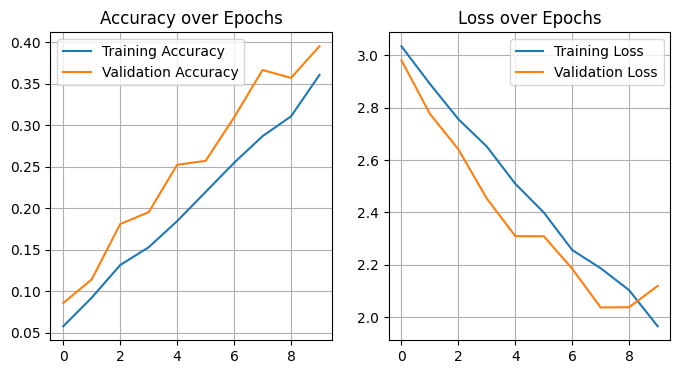

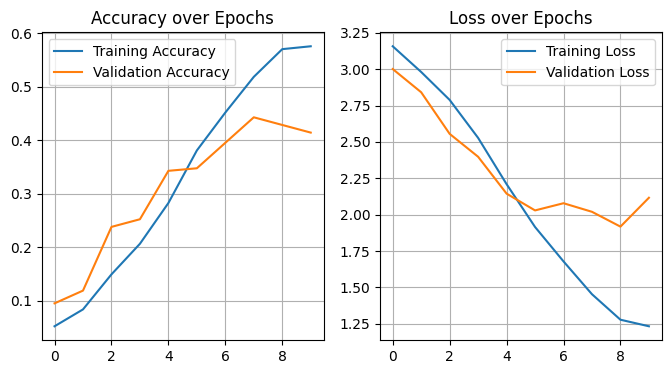

In [60]:
import matplotlib.pyplot as plt

def plot_history(history):
    plt.figure(figsize=(8,4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy over Epochs')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss over Epochs')
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot history for small model
plot_history(history_small)

# Plot history for large model
plot_history(history_large)


Modifying the Model and Adding Data Augmentation, Tuning the model for the large images to reduce the loss and improve accuracy.

In [61]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

# Create an image data generator for augmentation
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest')

# Modify CNN architecture slightly
model_large = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(242, 242, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(21, activation='softmax')
])

# Compile model with a slightly lower learning rate
model_large.compile(optimizer=Adam(learning_rate=0.0001),
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])

# Train model with data augmentation
history_large = model_large.fit(datagen.flow(Xdata_train, Ydata_train, batch_size=32),
                                epochs=20, 
                                validation_data=(Xdata_val, Ydata_val))


Epoch 1/20


c:\Users\Dell\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:120: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


53/53 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.0516 - loss: 3.1037 - val_accuracy: 0.0381 - val_loss: 3.0143
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step - accuracy: 0.0543 - loss: 3.0129 - val_accuracy: 0.0905 - val_loss: 2.9604
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.0754 - loss: 2.9674 - val_accuracy: 0.1190 - val_loss: 2.9089
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.0963 - loss: 2.9291 - val_accuracy: 0.1048 - val_loss: 2.8647
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.1075 - loss: 2.8683 - val_accuracy: 0.1762 - val_loss: 2.8186
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.1217 - loss: 2.8595 - val_accuracy: 0.1619 - val_loss: 2.7379
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.1357 - loss: 2.7948 - val_accuracy: 0.1714 - val_loss: 2.7104
Epoch 8/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.1460 - loss: 2.7813 - val_accuracy: 0.2238 - val_loss: 2.6287
Epo

Plotting Training and Validation Accuracy and Loss

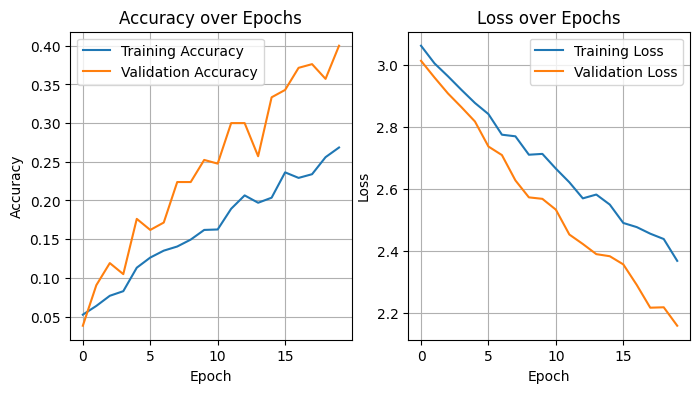

In [62]:
import matplotlib.pyplot as plt

def plot_history(history):
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    plt.show()


plot_history(history_large)


Evaluate the Model

In [63]:
# Evaluate model on the test set
test_loss, test_acc = model_large.evaluate(Xdata_test, Ydata_test)
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 225ms/step - accuracy: 0.4531 - loss: 2.0712
Test Accuracy: 41.90%
Test Loss: 2.1199


Preparing the Data with PCA, reducing the dimensions, using lower-dimensional data to train the SVM.

In [64]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Function to apply PCA and Standardization
def apply_pca(data, variance_retain):
    # Flatten the image data
    data_flattened = data.reshape(data.shape[0], -1)  # Reshape the data to 2D
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data_flattened)  # Standardize the data
    pca = PCA(n_components=variance_retain)  # Apply PCA
    principal_components = pca.fit_transform(data_scaled)
    return scaler, pca, principal_components

# PCA to the smaller images dataset (X_train is for smaller images)
scaler_small, pca_small, X_pca_small_train = apply_pca(X_train, 0.95)

# PCA to the larger images dataset (Xdata_train is for larger images)
scaler_large, pca_large, X_pca_large_train = apply_pca(Xdata_train, 0.95)


Model Setup

In [65]:
from sklearn.svm import SVC

# Configure SVM
svm_small = SVC(kernel='linear', C=1.0, random_state=42)
svm_large = SVC(kernel='linear', C=1.0, random_state=42)


Training

In [66]:
# Train SVM for smaller images
svm_small.fit(X_pca_small_train, Y_train)

# Train SVM for larger images
svm_large.fit(X_pca_large_train, Y_train)


SVC(kernel='linear', random_state=42)

Validation Testing

In [67]:
# Transform smaller images validation dataset
X_pca_small_val = pca_small.transform(scaler_small.transform(X_val.reshape(X_val.shape[0], -1)))

# Transform  larger images validation dataset
X_pca_large_val = pca_large.transform(scaler_large.transform(Xdata_val.reshape(Xdata_val.shape[0], -1)))


# Validation accuracy
val_accuracy_small = svm_small.score(X_pca_small_val, Y_val)
val_accuracy_large = svm_large.score(X_pca_large_val, Y_val)

print(f"Validation Accuracy (Small): {val_accuracy_small*100:.2f}%")
print(f"Validation Accuracy (Large): {val_accuracy_large*100:.2f}%")


Validation Accuracy (Small): 32.38%
Validation Accuracy (Large): 32.86%


In [68]:
# Transform smaller images test dataset
X_pca_small_test = pca_small.transform(scaler_small.transform(X_test.reshape(X_test.shape[0], -1)))

# Transform larger images test dataset
X_pca_large_test = pca_large.transform(scaler_large.transform(Xdata_test.reshape(Xdata_test.shape[0], -1)))

# Test accuracy
test_accuracy_small = svm_small.score(X_pca_small_test, Y_test)
test_accuracy_large = svm_large.score(X_pca_large_test, Y_test)

print(f"Test Accuracy (Small): {test_accuracy_small*100:.2f}%")
print(f"Test Accuracy (Large): {test_accuracy_large*100:.2f}%")


Test Accuracy (Small): 35.71%
Test Accuracy (Large): 34.76%


In [69]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Standardize training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.reshape(X_train.shape[0], -1))

# Fit PCA on the standardized training data
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)

# Standardize and transform validation data using the same scaler and PCA
X_val_scaled = scaler.transform(X_val.reshape(X_val.shape[0], -1))
X_val_pca = pca.transform(X_val_scaled)

# Train the SVM
svm_model = SVC(kernel='linear', C=1.0)
svm_model.fit(X_train_pca, Y_train)

# Evaluate the SVM on validation data
val_accuracy = svm_model.score(X_val_pca, Y_val)
print(f"Validation Accuracy: {val_accuracy*100:.2f}%")

# Similarly for the test data
X_test_scaled = scaler.transform(X_test.reshape(X_test.shape[0], -1))
X_test_pca = pca.transform(X_test_scaled)
test_accuracy = svm_model.score(X_test_pca, Y_test)
print(f"Test Accuracy: {test_accuracy*100:.2f}%")


Validation Accuracy: 32.38%
Test Accuracy: 35.71%


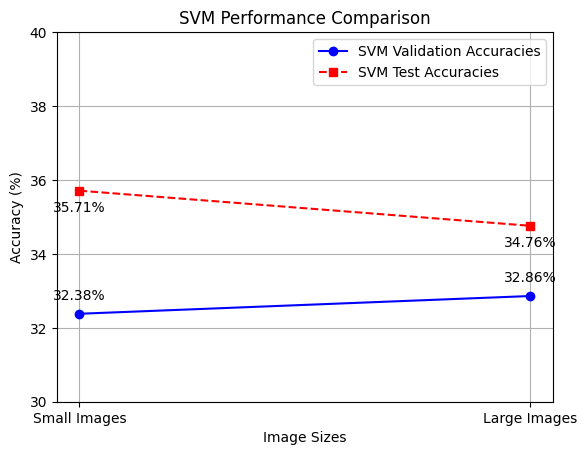

In [70]:
import numpy as np
import matplotlib.pyplot as plt

# Data points for SVM accuracies
svm_validation_accuracies = [32.38, 32.86]  # Validation accuracies for small and large images
svm_test_accuracies = [35.71, 34.76]  # Test accuracies for small and large images

labels = ['Small Images', 'Large Images']  # Categories
x = np.arange(len(labels))  # the label locations

fig, ax = plt.subplots()

# Plotting validation and test accuracies
ax.plot(labels, svm_validation_accuracies, marker='o', label='SVM Validation Accuracies', linestyle='-', color='b')
ax.plot(labels, svm_test_accuracies, marker='s', label='SVM Test Accuracies', linestyle='--', color='r')

# Adding details
ax.set_xlabel('Image Sizes')
ax.set_ylabel('Accuracy (%)')
ax.set_title('SVM Performance Comparison')
ax.legend()

# Set limits for Y axis
ax.set_ylim(30, 40)  # Setting the y-axis limits from 10% to 100%

# Annotate each point with the accuracy value
for i, txt in enumerate(svm_validation_accuracies):
    ax.annotate(f'{txt}%', (x[i], svm_validation_accuracies[i]), textcoords="offset points", xytext=(0,10), ha='center')
for i, txt in enumerate(svm_test_accuracies):
    ax.annotate(f'{txt}%', (x[i], svm_test_accuracies[i]), textcoords="offset points", xytext=(0,-15), ha='center')

plt.grid(True)  
plt.show()


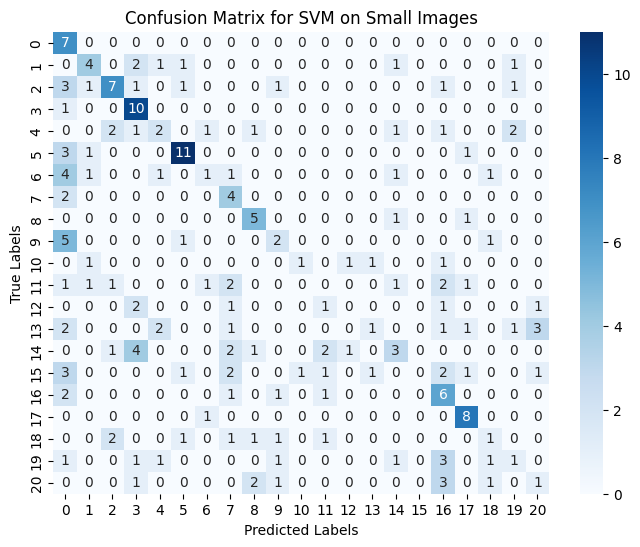

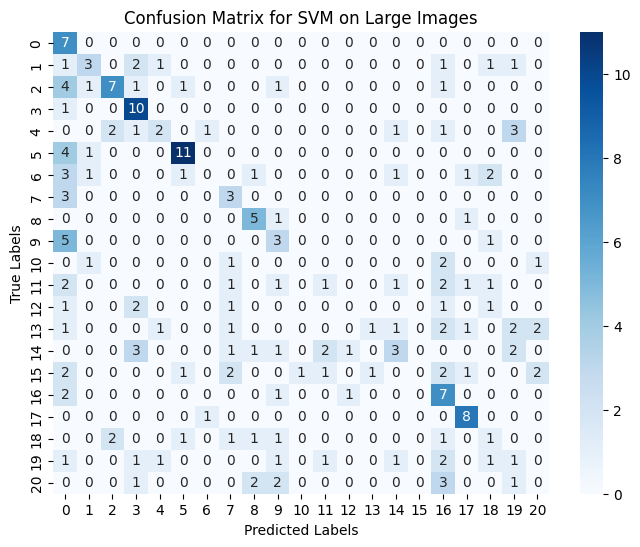

In [78]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Function to plot confusion matrix
def plot_confusion_matrix(cm, title='Confusion Matrix'):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap='Blues')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title(title)
    plt.show()

# Predict and plot for small images
y_pred_small = svm_small.predict(X_pca_small_test)  
cm_small = confusion_matrix(Y_test, y_pred_small)
plot_confusion_matrix(cm_small, 'Confusion Matrix for SVM on Small Images')

# Predict and plot for large images
y_pred_large = svm_large.predict(X_pca_large_test) 
cm_large = confusion_matrix(Ydata_test, y_pred_large)
plot_confusion_matrix(cm_large, 'Confusion Matrix for SVM on Large Images')


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


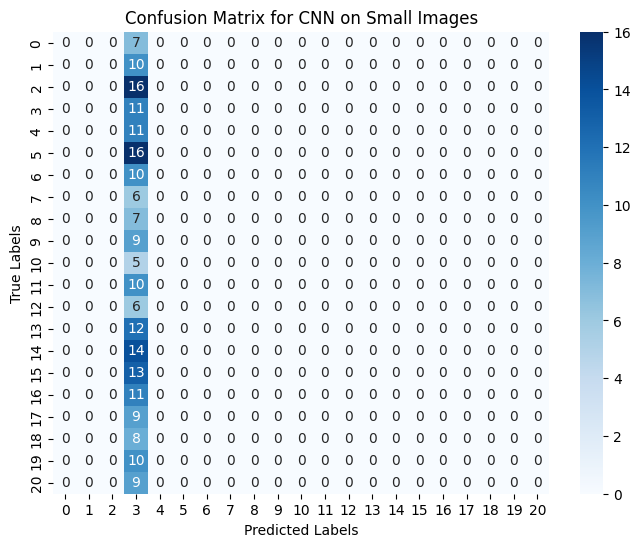

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 233ms/step


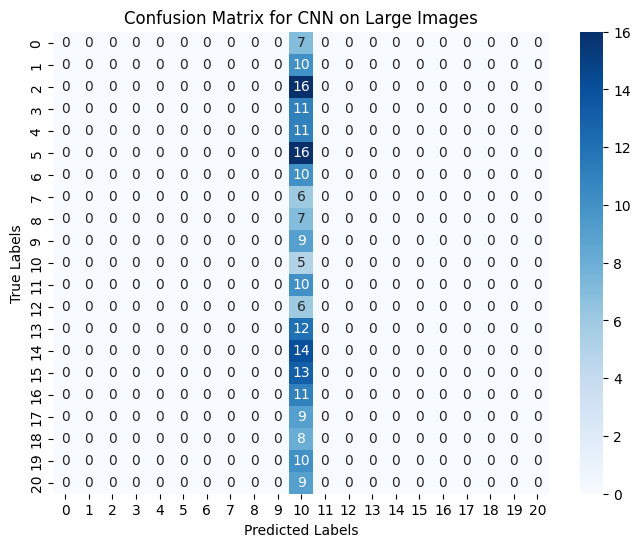

In [80]:
# model_small and model_large are trained CNN models
y_pred_small_cnn = model_small.predict(X_test).argmax(axis=1)  
cm_small_cnn = confusion_matrix(Y_test, y_pred_small_cnn)
plot_confusion_matrix(cm_small_cnn, 'Confusion Matrix for CNN on Small Images')

y_pred_large_cnn = model_large.predict(Xdata_test).argmax(axis=1)
cm_large_cnn = confusion_matrix(Ydata_test, y_pred_large_cnn)
plot_confusion_matrix(cm_large_cnn, 'Confusion Matrix for CNN on Large Images')


Visualization for the Accuracy Bar Chart

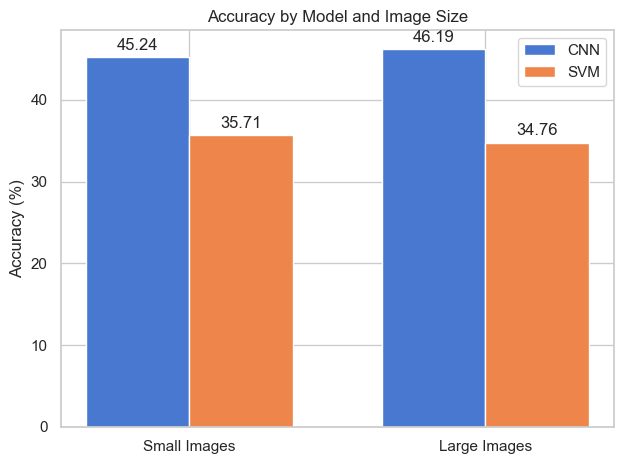

In [88]:
import matplotlib.pyplot as plt
import numpy as np

# Accuracy data 
cnn_accuracies = [45.24, 46.19]  # Small and Large Image accuracies for CNN
svm_accuracies = [35.71, 34.76]  # Small and Large Image accuracies for SVM

labels = ['Small Images', 'Large Images']
x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, cnn_accuracies, width, label='CNN')
rects2 = ax.bar(x + width/2, svm_accuracies, width, label='SVM')

.
ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy by Model and Image Size')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()


def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{}'.format(height),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.show()
